#ML FINAL EXAM

### Email: work.nafiz@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer: I choose this dataset because of the interest in finance world. So I can learn and practice in same time by choosing this kind of dataset.



# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


df = pd.read_csv("/content/aapl_us_2025.csv")
# df.sample(5)

print("Number of features :", df.shape[1])

print("Number of data points:", df.shape[0])

print("Total null:", df.isnull().sum().sum())

# print(df.dtypes)

# convert day to datetime
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)

# correlation among all features

num_df = df.select_dtypes(include='number')
corr = num_df.corr()
print(corr)



Number of features : 6
Number of data points: 10171
Total null: 0
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object
            Open      High       Low     Close    Volume
Open    1.000000  0.999947  0.999944  0.999883 -0.312547
High    0.999947  1.000000  0.999929  0.999945 -0.312283
Low     0.999944  0.999929  1.000000  0.999946 -0.312975
Close   0.999883  0.999945  0.999946  1.000000 -0.312631
Volume -0.312547 -0.312283 -0.312975 -0.312631  1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10171 entries, 0 to 10170
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    10171 non-null  datetime64[ns]
 1   Open    10171 non-null  float64       
 2   High    10171 non-null  float64       
 3   Low     10171 non-null  float64       
 4   Close   10171 non-null  float64       
 5   Volume  10171 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 476.9 KB


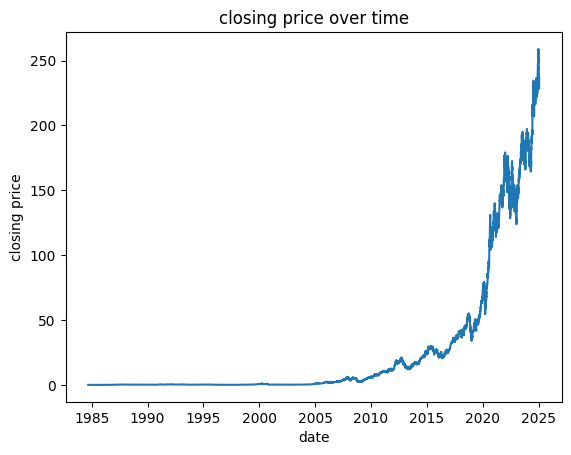

In [137]:
# for eda
df.info()
df.describe()

plt.plot(df['Date'], df['Close'])
plt.title("closing price over time")
plt.xlabel("date")
plt.ylabel("closing price")
plt.show()

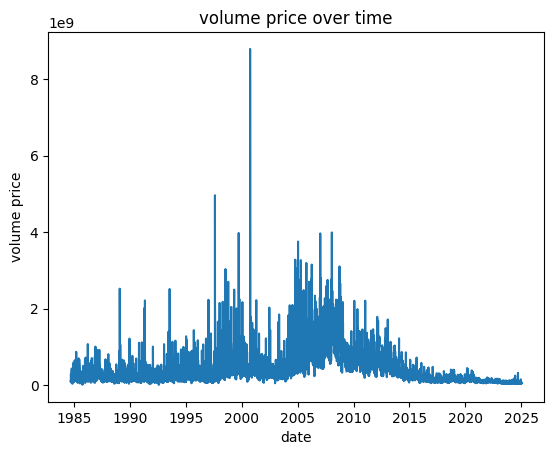

In [138]:
plt.plot(df['Date'], df['Volume'])
plt.title("volume price over time")
plt.xlabel("date")
plt.ylabel("volume price")
plt.show()

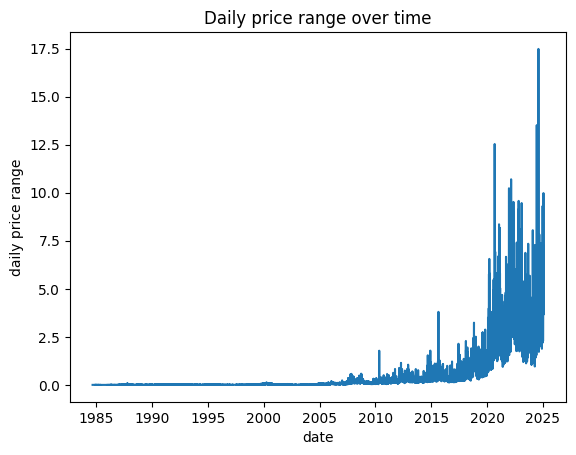

In [139]:
df['Daily_range'] = df['High'] - df['Low']
plt.plot(df['Date'], df['Daily_range'])
plt.title("Daily price range over time")
plt.xlabel("date")
plt.ylabel("daily price range")
plt.show()

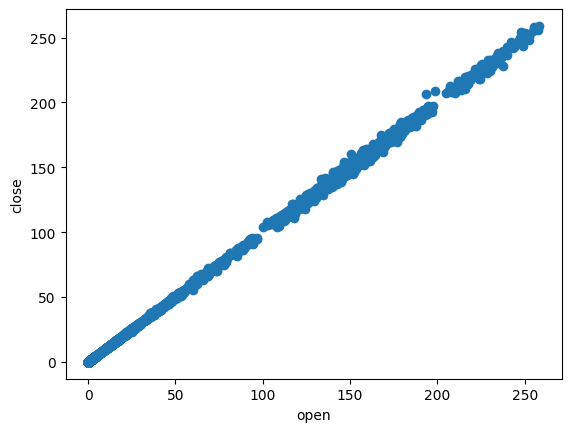

In [140]:
# open and close er parthokko
plt.scatter(df['Open'], df['Close'])
plt.xlabel("open")
plt.ylabel("close")
plt.show()

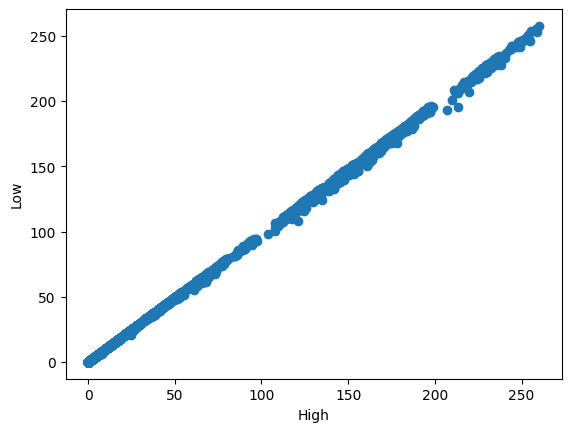

In [141]:
# high and low er parthokko
plt.scatter(df['High'], df['Low'])
plt.xlabel("High")
plt.ylabel("Low")
plt.show()

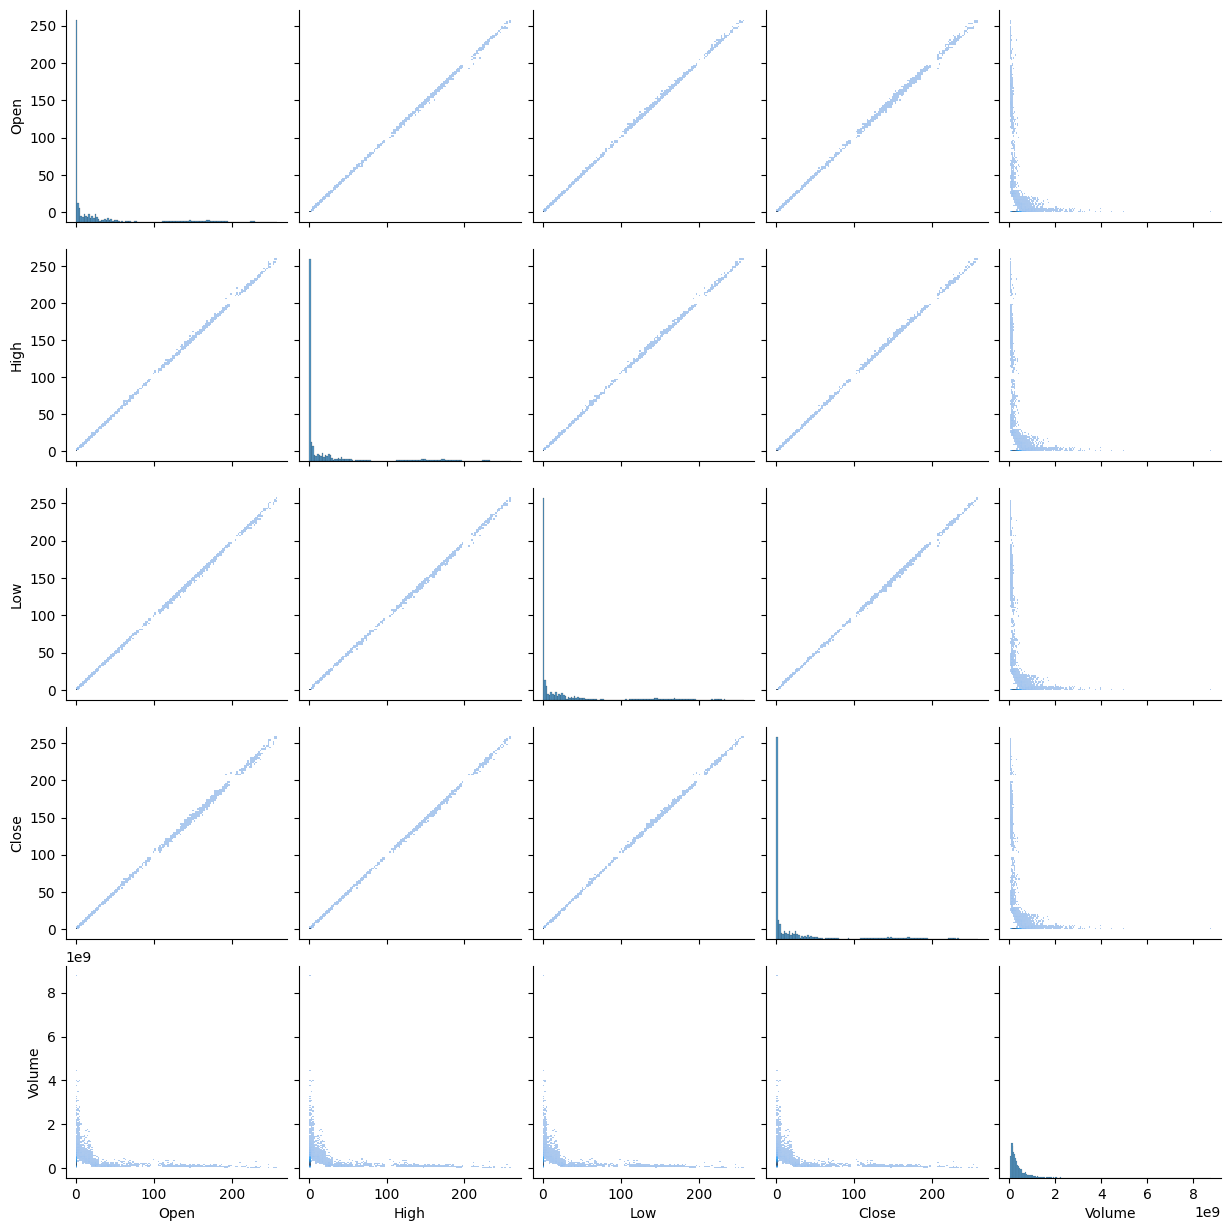

In [117]:
# all things in one chat

sns.pairplot(data=df[['Open', 'High', 'Low', 'Close', 'Volume']], kind='hist')
plt.show()

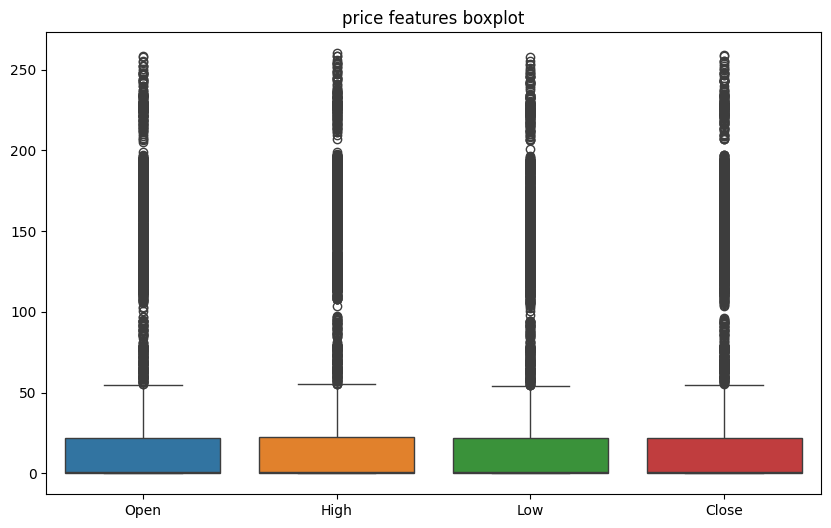

In [118]:
# for outlier
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])
plt.title('price features boxplot')
plt.show()

# but market e egula savabik tai amra chaileo ei extreme value ke outlier hisebe nite pari na


##Answer:





In [119]:
"""
2: Jehetu ami next day price upore naki niche jabe predict korbo tai eta ekta classification problem. etar jonno amra ekta notun column add korte pari 'target' name e.. rules hobe jodi porer diner closing price besi thake ager diner theke tahole price barbe. nahole price kombe. jetake amra 0 and 1 diye fill korbo.

5: dataset e muloto sob numerrical features royeche r ekta datetime features royeche.

6: amader dataset e categorical variable nei tai categorical variable encoding korte hobe na. date time e ektake convert kora hoyeche jetao categorical na.

7: sovabotoi stock er price onujayi open, high, low, close er majhe onek soktisali ekta correlation ache. khub e linear ekta linear somporko ache. r er karon holo era same trading day er different info. kintu kintu volume er sathe eder ekta negative corr ache. eder bolte volume er sathe open, high, low, close er sathe.


"""

"\n2: Jehetu ami next day price upore naki niche jabe predict korbo tai eta ekta classification problem. etar jonno amra ekta notun column add korte pari 'target' name e.. rules hobe jodi porer diner closing price besi thake ager diner theke tahole price barbe. nahole price kombe. jetake amra 0 and 1 diye fill korbo.\n\n5: dataset e muloto sob numerrical features royeche r ekta datetime features royeche.\n\n6: amader dataset e categorical variable nei tai categorical variable encoding korte hobe na. date time e ektake convert kora hoyeche jetao categorical na.\n\n7: sovabotoi stock er price onujayi open, high, low, close er majhe onek soktisali ekta correlation ache. khub e linear ekta linear somporko ache. r er karon holo era same trading day er different info. kintu kintu volume er sathe eder ekta negative corr ache. eder bolte volume er sathe open, high, low, close er sathe.\n\n\n"

#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [120]:
df.duplicated().sum()

np.int64(0)

In [121]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Daily_range,0


In [122]:
(df[['Open', 'High', 'Low', 'Close']] <= 0).sum()

,0
Open,0
High,0
Low,0
Close,0


In [123]:
(df['Volume'] < 0).sum()

np.int64(0)

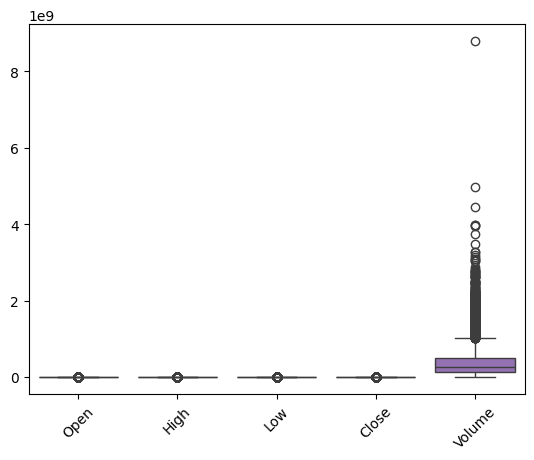

In [124]:
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close', 'Volume']])
plt.xticks(rotation=45)
plt.show()

In [125]:
df.drop(columns=['Date', 'Daily_range'], inplace=True)

tomorrows_close = df['Close'].values[1:]
todays_close = df['Close'].values[:-1]

df['Target'] = np.append((tomorrows_close > todays_close).astype(int), np.nan)

df = df.dropna(subset=['Target'].copy())
df['Target'] = df['Target'].astype(int)
df.shape

(10170, 6)

In [126]:
df.sample(10)

,Open,High,Low,Close,Volume,Target
6677,10.714400,10.728000,10.485200,10.534500,5.387180e+08,1
2026,0.369446,0.371354,0.358307,0.358970,2.130118e+08,1
8560,51.001400,51.540400,50.938000,51.227600,7.983617e+07,1
9029,90.230700,91.640000,90.199900,91.170900,1.216375e+08,0
4649,0.215006,0.219856,0.212074,0.216269,1.988074e+08,0
8002,22.475400,23.367400,22.373700,22.622600,9.935502e+07,1
9064,125.768000,125.848000,121.129000,122.995000,3.539929e+08,0
2682,0.290206,0.291156,0.282909,0.282909,2.737018e+08,0
6626,9.655450,9.741390,9.626820,9.662380,4.916534e+08,1
5606,2.788670,2.809240,2.699610,2.700580,1.272672e+09,1


#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



Date bad dibo. apadoto ami time dhore kaj korbo na eitar jonno. jodio ami jotodur jani trading e time dhore tarpor predict kora hyo.

open diner surur stock er price tai eta rakha hoyeche.
high diner highest price
low diner lowest price
close diner seser stock er dam tai egula egula rakha hoyeche.

r volume holo oi dine total ki amount er trade hoyeche setar information.

already amra eder moddhokar korelation dekhechi.

In [127]:
x = df.drop(columns=['Target'])
y = df['Target']

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

print("xtrain:", xtrain.shape)
print("xtest :", xtest.shape)
print("ytrain:", ytrain.shape)
print("ytest :", ytest.shape)

xtrain: (8136, 5)
xtest : (2034, 5)
ytrain: (8136,)
ytest : (2034,)


#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [128]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42))
    ]
)



# print(y_pred_lr)

In [129]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier())
    ]
)



# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [130]:
logistic_pipeline.fit(xtrain, ytrain)
y_pred_lr = logistic_pipeline.predict(xtest)

knn_pipeline.fit(xtrain, ytrain)
y_pred_knn = knn_pipeline.predict(xtest)

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [131]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# logistic regressio
lr_accuracy = accuracy_score(ytest, y_pred_lr)
lr_precision = precision_score(ytest, y_pred_lr)
lr_recall = recall_score(ytest, y_pred_lr)

# knn
knn_accuracy = accuracy_score(ytest, y_pred_knn)
knn_precision = precision_score(ytest, y_pred_knn)
knn_recall = recall_score(ytest, y_pred_knn)

result = pd.DataFrame(
    {
        'Category':['accuracy', 'precision', 'recall'],
        'logistic regression': [
            lr_accuracy,
            lr_precision,
            lr_recall
        ],
        'knn': [
            knn_accuracy,
            knn_precision,
            knn_recall
        ]
    }
)

print(result)

    Category  logistic regression       knn
0   accuracy             0.502950  0.495575
1  precision             0.523894  0.505837
2     recall             0.285164  0.500963


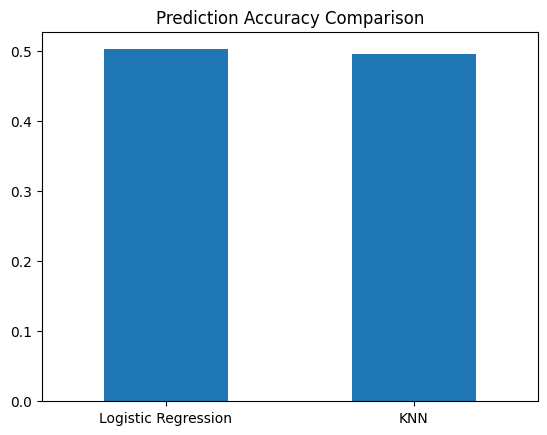

In [132]:
models = ['Logistic Regression', 'KNN']
accuracies = [lr_accuracy, knn_accuracy]

s = pd.Series([lr_accuracy, knn_accuracy], index=['Logistic Regression', 'KNN'])
s.plot(kind='bar', rot=0)

plt.title('Prediction Accuracy Comparison')
plt.show()

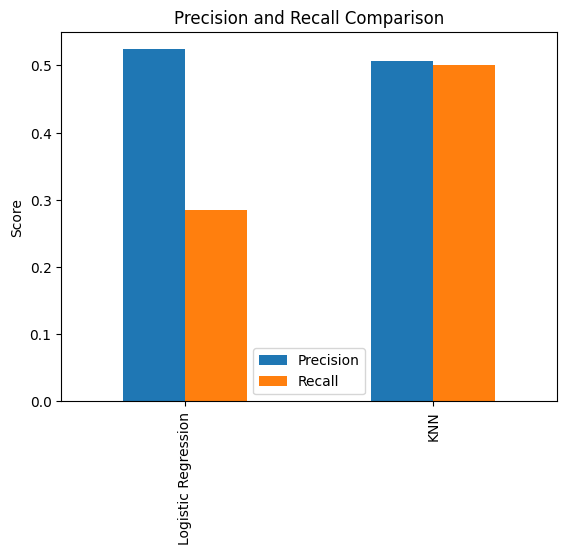

In [133]:
df = pd.DataFrame({
    'Precision': [lr_precision, knn_precision],
    'Recall': [lr_recall, knn_recall]
}, index=['Logistic Regression', 'KNN'])

df.plot(kind='bar')
plt.title('Precision and Recall Comparison')
plt.ylabel('Score')
plt.show()

[[488 508]
 [518 520]]


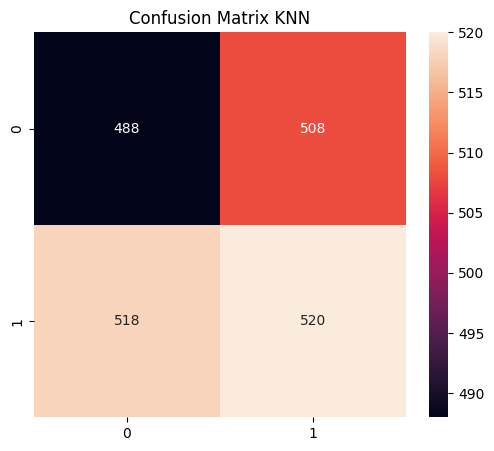

In [134]:
cm_knn = confusion_matrix(ytest, y_pred_knn)

print(cm_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title('Confusion Matrix KNN')
plt.show()

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

In [135]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=None, random_state= 42)
x_pca = pca.fit_transform(x_scaled)

variance_ratio = pca.explained_variance_ratio_
cum_variance=np.cumsum(variance_ratio)

print("Individual Explained Variance Ratios:")
print(variance_ratio)
print("\nCumulative Explained Variance:")
print(cum_variance)

pc1 = x_pca[:, 0]
pca_predictions = (pc1 > np.median(pc1)).astype(int)

acc_pca = accuracy_score(y, pca_predictions)
print("\n", "PCA accuracy: ", acc_pca * 100, "%")

Individual Explained Variance Ratios:
[8.24968648e-01 1.74990760e-01 2.34967114e-05 1.42222589e-05
 2.87339162e-06]

Cumulative Explained Variance:
[0.82496865 0.99995941 0.9999829  0.99999713 1.        ]

 PCA accuracy:  50.86529006882989 %


## to bola jay ei apple er data set e overall accuracy 50 er ase pasei ache.. supervised and unsupervised er PCA er khettre accuracy kind of same eseche..

## overall KNN 50 er ase pase diyeche (which is bad of course but finance er trading er data te er theke besi pete hole aro onek data lagte pare for better accuracy ja ei dataset e missing.

## r PCA Unsupervised eo 50% around accuracy.

## overall Supervised er KNN e ektu better

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:
still eitar ans deoyar time eo phitron book, online documentation dekhe korte hoyeche.

knn, random forest, dbscan amar kache hard lagse ektu..
baki gula amar kache easy silo.

real world e ami finance world er proti ektu interested and sekhane dekhlam time related something kora hoy r onnanno data gula eisob use korle prediction gulo 50-60 er upore nite pari nai. ei exam eo 50+ gese but er upre jay nai r.. maybe aro sikha lagbe tarpor finance, trading data analysis korte parbo proper.

specifically jodi boli price prediction, maybe future e algo make kora personal for researh the market and work in BD finance market researcher. eikhane ekta valo future ache bangladesh e.

also unsupervised asole kivabe koi kaje lage eita niye aro jante hobe. NB: ami hoyto kisu miss korte pari karon ami ei2 mas ektu tene tene ba sudhu book pore agaisi consistent thakar jonno nahole kono track ei thaka possible hoito na amar jono.

overall etai. easy topic silo eda, split, scalling, encoding, classification, logistic regression, k nearest neighbour, support vector easy silo

